In [1]:
"""
Transportability of Causal Effects — PyMC translation of the R/Stan example

Real data example based on House et al., 2020 (Model_6a_6b_6c_6d_data.csv)
This script:
  1) Loads and prepares the dataset (conditions, age recode, gender recode, site-by-age demo matrix)
  2) Fits two models with PyMC:
       - Basic empirical model (per-site intercept & treatment effect), outputs per-site causal effect on outcome scale
       - Transport GP model: per-site Gaussian Process over age modifies the treatment effect; transports effects to a
         chosen reference population using that population's age distribution
  3) Reproduces an analog of Fig. 5: densities of empirical vs transported effects per population.

Dependencies: numpy, pandas, matplotlib, arviz, pymc, pytensor, scipy
"""
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from scipy.special import expit
from pathlib import Path

## Helpers

In [2]:
# -----------------------------
# Data prep
# -----------------------------

def load_house2020(csv_path: str | Path, ref_index: int = 6):
    """Load and prepare the House et al. (2020) dataset.

    Returns a dict d_list compatible with the original Stan code, plus metadata.
    - condition: 0/1 after dropping condition==3 ("both ok"). 0 = "Generous", 1 = "Selfish" (following R script order).
    - age recoded: original 4..15 → 1..12 by subtracting 3 (so MA=12).
    - gender recode: 1 = male, 2 = female (original GENDER_1female is 0/1, hence +1 makes female→2).
    - pop_id: 1..N_pop, derived from categorical codes of fieldid preserving pandas order.
    - Demo: N_pop × MA matrix of sample counts per site and (recoded) age, pooled over genders.
    """
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    # Build condition column = which of the 3 CONDITION_* columns equals 1 (1..3)
    cond_cols = ["CONDITION_1_1yes", "CONDITION_2_1yes", "CONDITION_3_1yes"]
    # idxmax returns position of the max; add 1 to match 1..3 indexing like which() in R
    cond_idx = df[cond_cols].values.argmax(axis=1) + 1

    df = pd.DataFrame({
        "SUBJECT_ID": df["SUBJECT_ID"],
        "GENDER_1female": df["GENDER_1female"],
        "fieldid": df["fieldid"],
        "AGE_in_years": df["AGE_in_years"],
        "condition": cond_idx,
        "choice": df["T1_choice_1yes"].astype(int),
    })

    # Round ages to nearest int, recode, filter conditions
    df["age"] = df["AGE_in_years"].round().astype(int)
    df["gender"] = (df["GENDER_1female"].astype(int) + 1).astype(int)  # 1=male, 2=female

    # Drop condition==3 ("both ok") and recode to 0/1
    df = df[df["condition"] != 3].copy()
    df["condition01"] = (df["condition"] - 1).astype(int)

    # Recode ages: original 4..15 → 1..12 by subtracting 3
    df["age_recoded"] = (df["age"] - 3).astype(int)

    # Pop IDs as 1..N_pop
    pop_codes, uniques = pd.factorize(df["fieldid"], sort=True)
    df["pop_id"] = pop_codes + 1
    N_pop = len(uniques)

    # MA fixed to 12 per R code
    MA = 12

    # Build Demo: N_pop × MA counts by site and recoded age (pooled genders)
    Demo = np.zeros((N_pop, MA), dtype=int)
    for j in range(1, N_pop + 1):
        for a in range(1, MA + 1):
            Demo[j - 1, a - 1] = int(((df["pop_id"] == j) & (df["age_recoded"] == a)).sum())

    # Pack Stan-like data list
    d_list = {
        "N": df.shape[0],
        "N_pop": N_pop,
        "MA": MA,
        "pop_id": df["pop_id"].to_numpy(),
        "age": df["age_recoded"].to_numpy(),
        "condition": df["condition01"].to_numpy(),
        "outcome": df["choice"].to_numpy().astype(int),
        "gender": df["gender"].to_numpy(),
        "Demo": Demo,
        "Ref": ref_index,
        "site_levels": list(map(str, uniques)),
    }

    # If these are the 6 sites from the paper, you can optionally overwrite nicer labels:
    if N_pop == 6:
        d_list["site_names"] = [
            "Berlin (GER)", "La Plata (ARG)", "Phoenix (USA)",
            "Pune (IND)", "Shuar (ECU)", "Wichí (ARG)"
        ]
    else:
        d_list["site_names"] = d_list["site_levels"]

    return d_list

In [3]:
# -----------------------------
# Empirical model (basic)
# -----------------------------

def fit_empirical(d_list, draws=2500, tune=2500, chains=4, seed=1, target_accept=0.99, max_treedepth=15):
    """Empirical per-site model:
        y_i ~ BernoulliLogit( alpha[site_i] + b_prime[site_i] * condition_i )
       With deterministic per-site causal effect on outcome scale:
        empirical_p[h] = sigmoid(alpha[h]) - sigmoid(alpha[h] + b_prime[h])
    """
    N = int(d_list["N"]) ; N_pop = int(d_list["N_pop"]) ; MA = int(d_list["MA"])
    pop_id = d_list["pop_id"].astype(int) - 1
    cond = d_list["condition"].astype(int)
    y = d_list["outcome"].astype(int)

    with pm.Model() as m:
        alpha = pm.Normal("alpha", mu=0.0, sigma=2.0, shape=N_pop)
        b_prime = pm.Normal("b_prime", mu=0.0, sigma=2.0, shape=N_pop)

        lin = alpha[pop_id] + b_prime[pop_id] * cond
        pm.Bernoulli("y", logit_p=lin, observed=y)

        # per-site causal effect (control minus treatment prob)
        empirical_p = pm.Deterministic("empirical_p", pm.math.sigmoid(alpha) - pm.math.sigmoid(alpha + b_prime))

        idata = pm.sample(draws=draws, tune=tune, chains=chains, random_seed=seed,
                          target_accept=target_accept, max_treedepth=max_treedepth)
    return idata


# -----------------------------
# Transport model (GP over age modifying treatment effect)
# -----------------------------

def fit_transport_gp(d_list, draws=2500, tune=2500, chains=4, seed=2, target_accept=0.99, max_treedepth=15):
    """PyMC counterpart of model_transport.stan.

    age_effect[h, a] ~ MVN(0, Sigma_h) with Sigma_h = sigma_h^2 * Rho_h, and
    Rho_h[i,j] = 1 (i=j) else rho_h * exp( -eta_h * ( (i-j)^2 / MA^2 ) )

    Linear predictor:
        logit p_i = alpha[site_i] + (b_prime[site_i] + age_effect[site_i, age_i]) * condition_i

    Transport to reference population `Ref` by age-composition weights Demo[Ref, :].
    """
    N = int(d_list["N"]) ; N_pop = int(d_list["N_pop"]) ; MA = int(d_list["MA"])
    pop_id = d_list["pop_id"].astype(int) - 1
    age = d_list["age"].astype(int) - 1  # 0..MA-1
    cond = d_list["condition"].astype(int)
    y = d_list["outcome"].astype(int)
    Demo = np.asarray(d_list["Demo"], dtype=float)
    Ref = int(d_list["Ref"]) - 1

    # Precompute squared distance matrix for age GP
    idx = np.arange(MA)
    D2_np = ((idx[None, :] - idx[:, None]) ** 2).astype(float) / (MA ** 2)
    I_np = np.eye(MA)

    with pm.Model() as m:
        alpha = pm.Normal("alpha", mu=0.0, sigma=2.0, shape=N_pop)
        b_prime = pm.Normal("b_prime", mu=0.0, sigma=2.0, shape=N_pop)

        eta = pm.Exponential("eta", lam=2.0, shape=N_pop)
        sigma = pm.Exponential("sigma", lam=1.0, shape=N_pop)
        rho = pm.Beta("rho", alpha=10.0, beta=1.0, shape=N_pop)

        D2 = pt.as_tensor_variable(D2_np)
        I = pt.as_tensor_variable(I_np)

        age_rows = []
        for h in range(N_pop):
            base = rho[h] * pt.exp(-eta[h] * D2)
            Rho_h = base * (1.0 - I) + I
            L_h = pt.linalg.cholesky(Rho_h)
            L_scaled = sigma[h] * L_h
            age_h = pm.MvNormal(f"age_effect_pop{h}", mu=pt.zeros((MA,)), chol=L_scaled, shape=(MA,))
            age_rows.append(age_h)
        age_effect = pt.stack(age_rows, axis=0)  # (N_pop, MA)
        age_effect = pm.Deterministic("age_effect", age_effect)

        lin = alpha[pop_id] + (b_prime[pop_id] + age_effect[pop_id, age]) * cond
        pm.Bernoulli("y", logit_p=lin, observed=y)

        # Empirical per-site effect (for plotting alongside transported)
        empirical_p = pm.Deterministic("empirical_p", pm.math.sigmoid(alpha) - pm.math.sigmoid(alpha + b_prime))

        # Transport: use reference population's age composition
        Demo_ref = pt.as_tensor_variable(Demo[Ref, :])  # (MA,)
        # For each site h, effect_by_age[h, a] = P0 - P1(age)
        P0 = pm.math.sigmoid(alpha)[:, None]  # (N_pop,1)
        P1 = pm.math.sigmoid(alpha[:, None] + (b_prime[:, None] + age_effect))  # (N_pop, MA)
        effect_by_age = P0 - P1  # (N_pop, MA)
        transport_p = pm.Deterministic(
            "transport_p",
            (effect_by_age * Demo_ref[None, :]).sum(axis=1) / Demo_ref.sum(),
        )

        idata = pm.sample(draws=draws, tune=tune, chains=chains, random_seed=seed,
                          target_accept=target_accept, max_treedepth=max_treedepth)
    return idata

In [4]:
# -----------------------------
# Plot (Fig. 5 analog)
# -----------------------------

def plot_transport_fig5(idata_basic: az.InferenceData, idata_transport: az.InferenceData,
                        site_names: list[str], xlim=(-0.3, 0.9), outpath: str | Path | None = None):
    """Plot densities of empirical vs transported effects for each site."""
    K = len(site_names)
    assert K == idata_basic.posterior["empirical_p"].shape[-1] == idata_transport.posterior["transport_p"].shape[-1]

    cols = plt.get_cmap("Dark2")(np.linspace(0, 1, max(8, K)))

    fig, axes = plt.subplots(3, 2, figsize=(8, 10), sharex=True, sharey=False)
    axes = axes.ravel()

    emp = idata_basic.posterior["empirical_p"].values.reshape(-1, K)
    trn = idata_transport.posterior["transport_p"].values.reshape(-1, K)

    for i in range(K):
        ax = axes[i]
        c = cols[i]
        # KDE via numpy histogram approximation (simple & robust)
        xs = np.linspace(xlim[0], xlim[1], 512)
        # Use numpy histogram + gaussian filter-like smoothing via np.convolve with a small kernel if desired
        # For simplicity here, use numpy histogram density and line/filled area
        hist_emp, bin_edges = np.histogram(emp[:, i], bins=80, range=xlim, density=True)
        mids = 0.5 * (bin_edges[1:] + bin_edges[:-1])
        ax.fill_between(mids, hist_emp, step="mid", alpha=0.7, color=c, label="Empirical")

        hist_trn, _ = np.histogram(trn[:, i], bins=80, range=xlim, density=True)
        ax.fill_between(mids, hist_trn, step="mid", alpha=0.25, color=c, label="Transported")

        ax.axvline(0.0, ls="--", c="k", lw=1)
        ax.set_title(site_names[i], fontsize=9)
        ax.set_yticks([])

    # Hide any extra axes if K<6
    for j in range(K, len(axes)):
        axes[j].axis("off")

    fig.suptitle("'Transport' of causal effects across populations", y=0.98)
    fig.text(0.5, 0.04, "Effect of norm prime on prosocial choices", ha="center")
    axes[0].legend(loc="upper right", fontsize=8)
    fig.tight_layout(rect=(0, 0.03, 1, 0.95))

    if outpath is not None:
        fig.savefig(outpath, dpi=200)
    return fig

## Run

Loaded 487 rows; N_pop=6; MA=12. Sites: ['Berlin (GER)', 'La Plata (ARG)', 'Phoenix (USA)', 'Pune (IND)', 'Shuar (ECU)', 'Wichí (ARG)']


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, b_prime]


Output()

Sampling 4 chains for 2_500 tune and 2_500 draw iterations (10_000 + 10_000 draws total) took 8 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, b_prime, eta, sigma, rho, age_effect_pop0, age_effect_pop1, age_effect_pop2, age_effect_pop3, age_effect_pop4, age_effect_pop5]


Output()

Sampling 4 chains for 2_500 tune and 2_500 draw iterations (10_000 + 10_000 draws total) took 16773 seconds.
There were 26 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Saved outputs to: /mnt/c/Users/risto/projects/Cross-Cultural-Generalizability/outputs_transport


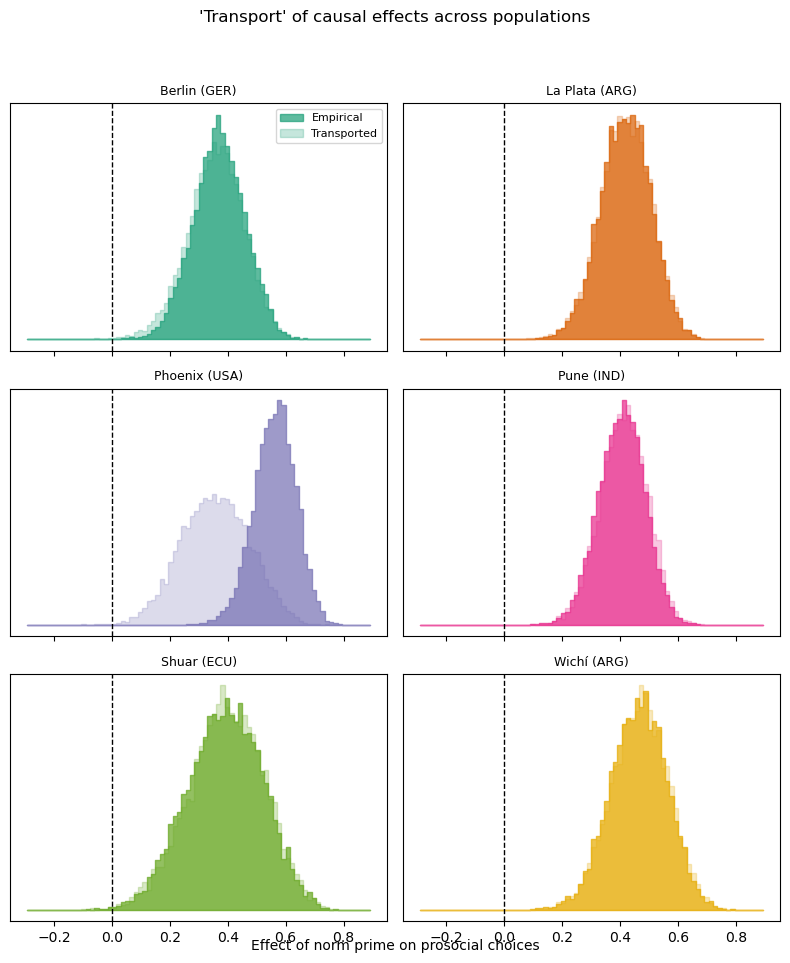

In [5]:
data_path = Path("data/Model_6a_6b_6c_6d_data.csv")
d_list = load_house2020(data_path, ref_index=6)  # Ref=6 → Wichí

print(f"Loaded {d_list['N']} rows; N_pop={d_list['N_pop']}; MA={d_list['MA']}. Sites: {d_list['site_names']}")

# Fit models
idata_basic = fit_empirical(d_list, seed=11)
idata_transport = fit_transport_gp(d_list, seed=22)

# Plot Fig.5 analog
outdir = Path("./outputs_transport")
outdir.mkdir(parents=True, exist_ok=True)

_ = plot_transport_fig5(idata_basic, idata_transport, d_list["site_names"],
                        outpath=outdir/"transport_fig5.png")

print("Saved outputs to:", outdir.resolve())

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'b_prime'}>,
        <Axes: title={'center': 'b_prime'}>],
       [<Axes: title={'center': 'empirical_p'}>,
        <Axes: title={'center': 'empirical_p'}>]], dtype=object)

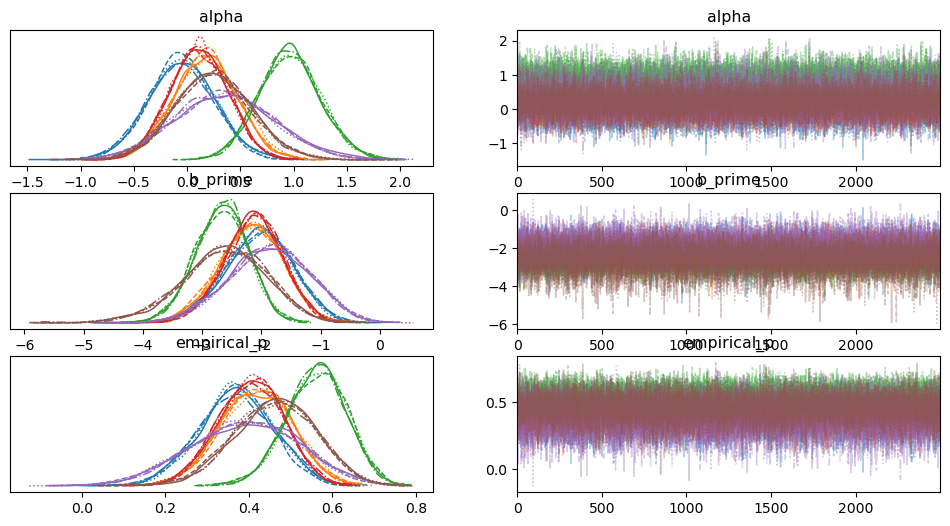

In [6]:
az.plot_trace(idata_basic)

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'b_prime'}>,
        <Axes: title={'center': 'b_prime'}>],
       [<Axes: title={'center': 'age_effect_pop0'}>,
        <Axes: title={'center': 'age_effect_pop0'}>],
       [<Axes: title={'center': 'age_effect_pop1'}>,
        <Axes: title={'center': 'age_effect_pop1'}>],
       [<Axes: title={'center': 'age_effect_pop2'}>,
        <Axes: title={'center': 'age_effect_pop2'}>],
       [<Axes: title={'center': 'age_effect_pop3'}>,
        <Axes: title={'center': 'age_effect_pop3'}>],
       [<Axes: title={'center': 'age_effect_pop4'}>,
        <Axes: title={'center': 'age_effect_pop4'}>],
       [<Axes: title={'center': 'age_effect_pop5'}>,
        <Axes: title={'center': 'age_effect_pop5'}>],
       [<Axes: title={'center': 'eta'}>, <Axes: title={'center': 'eta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: tit

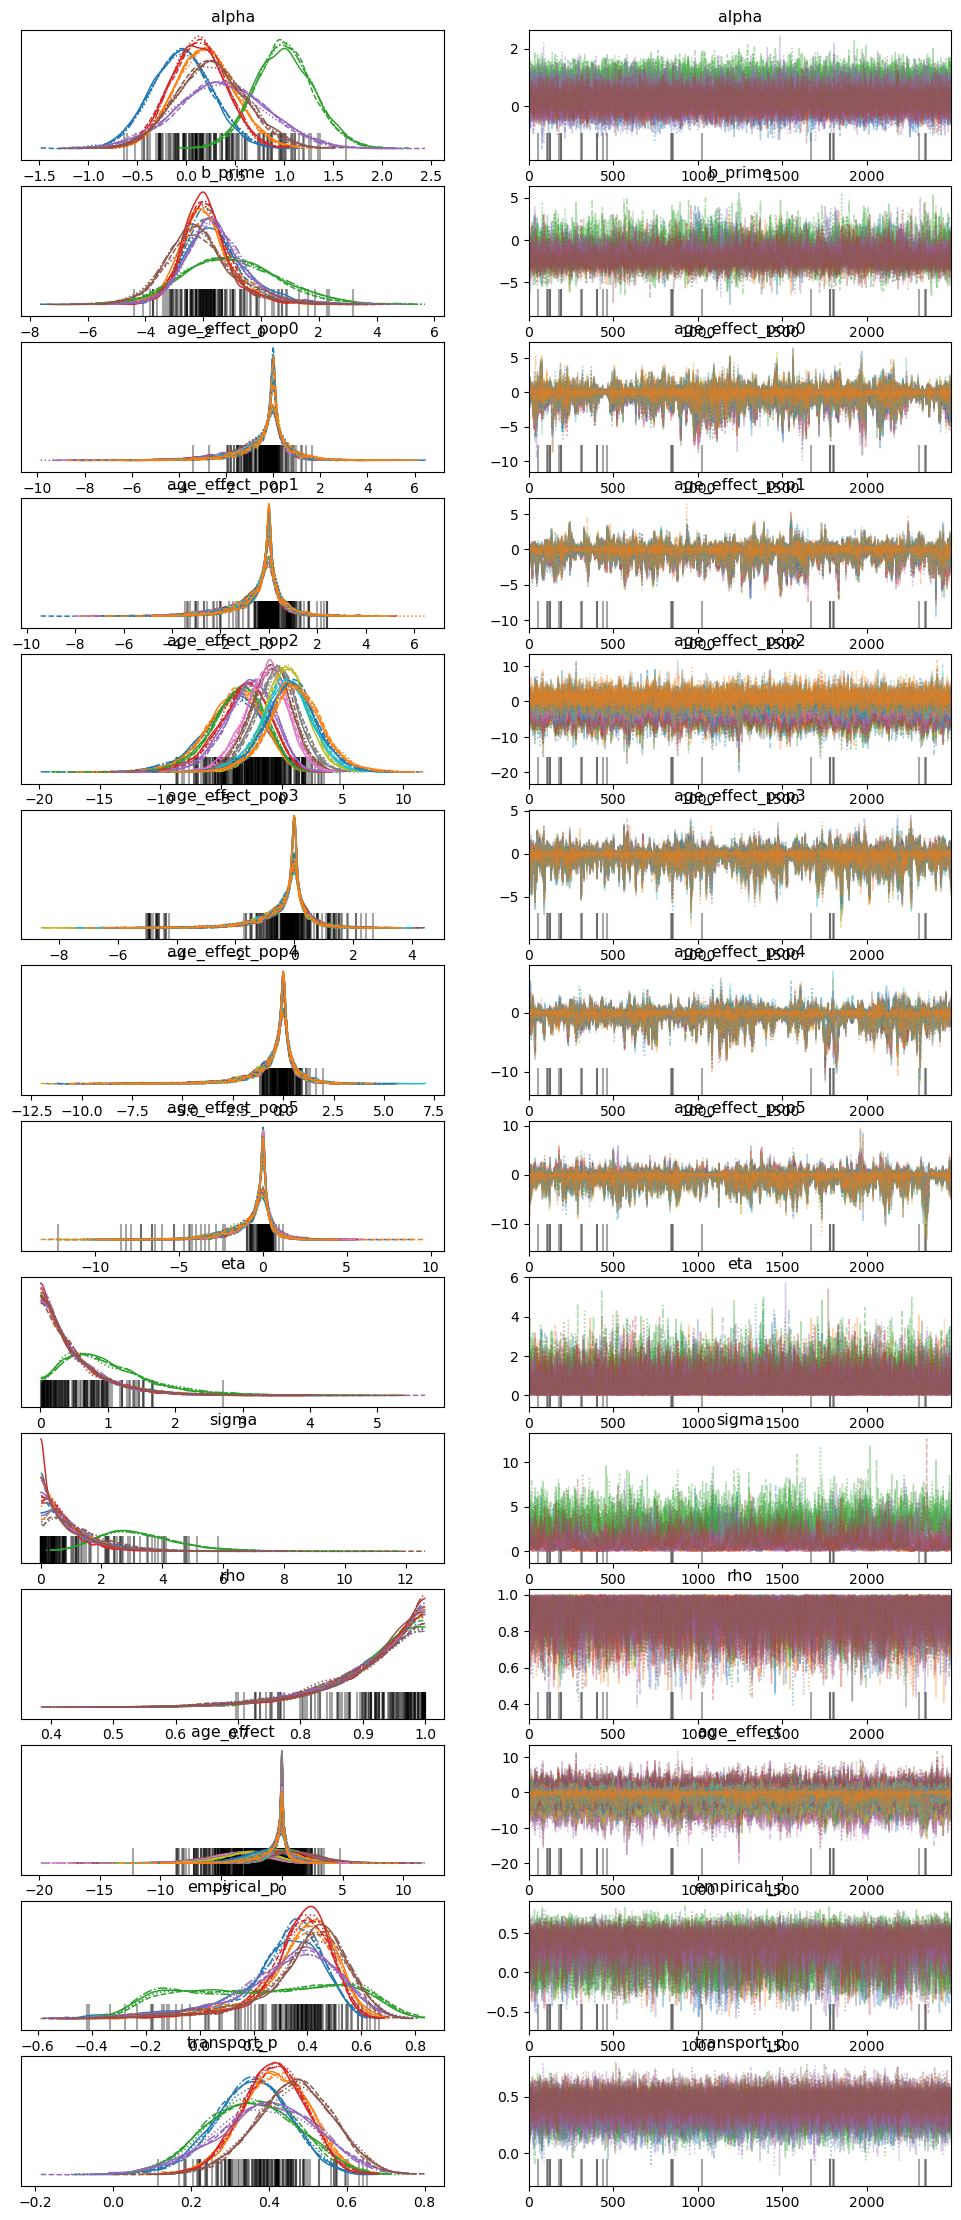

In [7]:
az.plot_trace(idata_transport)

In [8]:
df_summary_basic=az.summary(idata_basic)

In [9]:
df_summary_transport=az.summary(idata_transport)

In [12]:
df_summary_basic.sort_values('r_hat', ascending=False).head()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],-0.053,0.312,-0.645,0.528,0.004,0.003,7923.0,6872.0,1.0
alpha[1],0.177,0.300,-0.392,0.732,0.003,0.003,9017.0,7362.0,1.0
alpha[2],0.964,0.290,0.447,1.533,0.003,0.003,8534.0,6981.0,1.0
alpha[3],0.109,0.276,-0.406,0.621,0.003,0.003,8172.0,6692.0,1.0
alpha[4],0.348,0.467,-0.524,1.225,0.005,0.004,7761.0,6949.0,1.0


In [13]:
df_summary_transport.sort_values('r_hat', ascending=False).head()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma[5],1.109,0.998,0.005,2.892,0.093,0.046,70.0,244.0,1.05
sigma[3],0.772,0.713,0.004,2.030,0.044,0.023,155.0,290.0,1.03
"age_effect[5, 3]",-0.482,1.187,-3.120,1.521,0.038,0.051,1259.0,1223.0,1.02
"age_effect[5, 4]",-0.398,1.119,-2.883,1.470,0.033,0.045,1344.0,1418.0,1.02
"age_effect[5, 0]",-0.367,1.203,-3.068,1.645,0.031,0.055,1796.0,1518.0,1.02


In [14]:
df_summary_transport[df_summary_transport.r_hat>1.01].shape

(25, 9)